<a href="https://colab.research.google.com/github/Hadeel-93/HW-3/blob/main/HW_3Q_2%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn import datasets
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Load the breast cancer dataset
cancer = datasets.load_breast_cancer()

# Create X from the features
X = cancer.data

# Create y from output
y = cancer.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [4]:
# Create a scaler object
sc = StandardScaler()

# Fit the scaler to the training data and transform
X_train_std = sc.fit_transform(X_train)

# Apply the scaler to the test data
X_test_std = sc.transform(X_test)

In [5]:
C = [10, 1, .1, .001]

for c in C:
    clf = LogisticRegression(penalty='l1', C=c, solver='liblinear')
    clf.fit(X_train, y_train)
    print('C:', c)
    print('Training accuracy:', clf.score(X_train_std, y_train))
    print('Test accuracy:', clf.score(X_test_std, y_test))
    print('')

C: 10
Training accuracy: 0.9186813186813186
Test accuracy: 0.8947368421052632



/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C: 1
Training accuracy: 0.4989010989010989
Test accuracy: 0.5

C: 0.1
Training accuracy: 0.2043956043956044
Test accuracy: 0.19298245614035087

C: 0.001
Training accuracy: 0.13406593406593406
Test accuracy: 0.12280701754385964



/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [6]:
C = [10, 1, .1, .001]

for c in C:
    clf = LogisticRegression(penalty='l1', C=c, solver='liblinear')

    # Train using standardized data
    clf.fit(X_train_std, y_train)

    print('C:', c)
    print('Training accuracy:', clf.score(X_train_std, y_train))
    print('Test accuracy:', clf.score(X_test_std, y_test))
    print('')

C: 10
Training accuracy: 0.989010989010989
Test accuracy: 0.9473684210526315

C: 1
Training accuracy: 0.989010989010989
Test accuracy: 0.956140350877193

C: 0.1
Training accuracy: 0.9758241758241758
Test accuracy: 0.9736842105263158

C: 0.001
Training accuracy: 0.3626373626373626
Test accuracy: 0.41228070175438597



In [7]:
# As C decreases, the L1 regularization penalty becomes stronger,
# causing the model coefficients to become smaller.
# With sufficiently strong regularization, some coefficients may become zero,
# meaning that some of the 30 features have little or no contribution to the model.

In [9]:
kfold = KFold(n_splits=10, shuffle=True, random_state=0)
model = LogisticRegression(solver='liblinear')
results = cross_val_score(model, X_train_std, y_train, cv=kfold)

print("Accuracy: %.3f%% (%.3f%%)" %
      (results.mean()*100.0, results.std()*100.0))

Accuracy: 97.585% (2.286%)


In [11]:
model.fit(X_train_std, y_train)
# Predict using the test data
predicted = model.predict(X_test_std)

# Construct a confusion matrix
matrix = confusion_matrix(y_test, predicted)

print(matrix)

[[45  2]
 [ 2 65]]


In [12]:
# Create the logistic regression model
model = LogisticRegression(solver='liblinear')

# Train using the standardized training data
model.fit(X_train_std, y_train)

# Make predictions using the standardized test data
predicted = model.predict(X_test_std)

# Generate classification report
report = classification_report(y_test, predicted)

print(report)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        47
           1       0.97      0.97      0.97        67

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



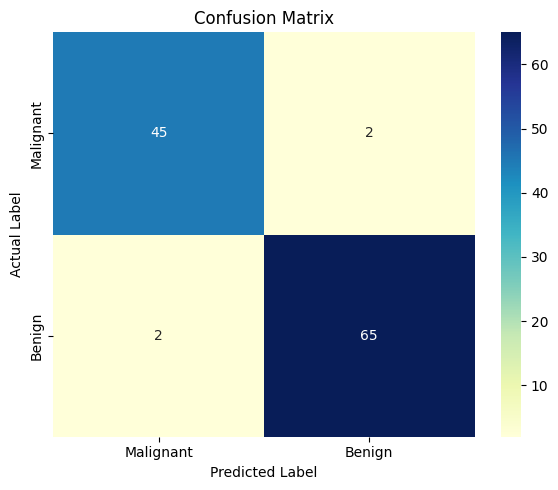

In [13]:
# Visualize the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Class names for the breast cancer dataset
class_names = ['Malignant', 'Benign']

# Create the confusion matrix
matrix = confusion_matrix(y_test, predicted)

# Plot the heatmap
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    matrix,
    annot=True,
    cmap="YlGnBu",
    fmt='g',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)

plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()